In [1]:
# Option A: Simple install
#!pip install requests pandas matplotlib  ta-lib

/tmp/ipykernel_7031/1559534998.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.586222798648897' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, "Sell_Signal"] = df["high"].iloc[i] * 1.01  # Place marker above candle
/tmp/ipykernel_7031/1559534998.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.285572090689817' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, "Buy_Signal"] = df["low"].iloc[i] * 0.99  # Place marker below candle


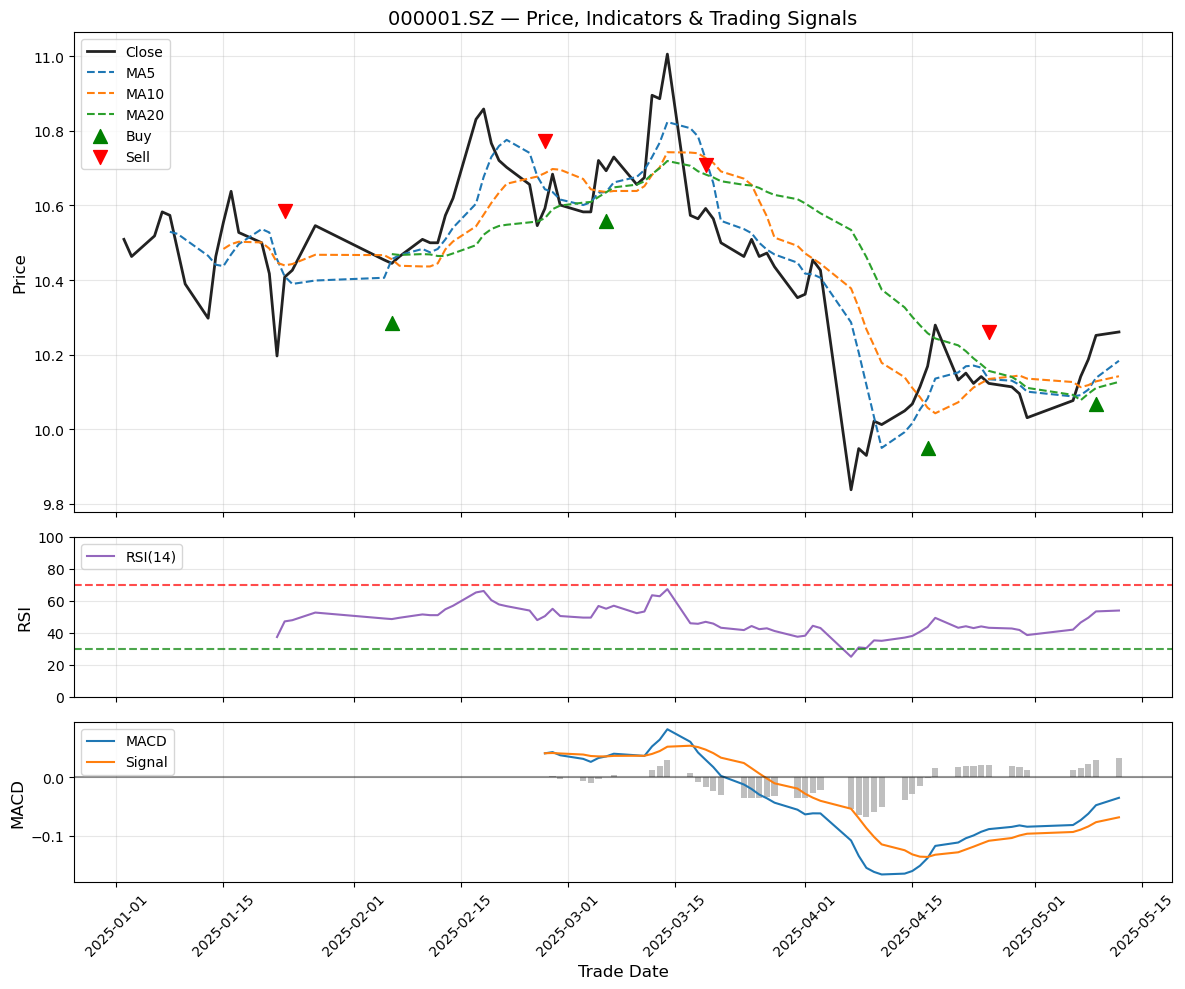

✅ Done! Data and signals saved to CSV.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import talib

# Create folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# --------------------------
# 1. Fetch & clean data
# --------------------------
df = yf.download(
    tickers="000001.SZ",
    start="2025-01-01",
    end="2025-05-13",
    progress=False
)

# Fix YFinance multi-index structure
df = df.droplevel("Ticker", axis=1)
df = df.reset_index()
df = df.rename(columns={
    "Date": "trade_date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "vol"
})

df = df[["trade_date", "open", "high", "low", "close", "vol"]]
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)

# --------------------------
# 2. Calculate indicators with TA-Lib
# --------------------------
close = df["close"].values

df["MA5"] = talib.SMA(close, timeperiod=5)
df["MA10"] = talib.SMA(close, timeperiod=10)
df["MA20"] = talib.SMA(close, timeperiod=20)
df["RSI"] = talib.RSI(close, timeperiod=14)

macd, macd_signal, macd_hist = talib.MACD(close, 12, 26, 9)
df["MACD"] = macd
df["MACD_Signal"] = macd_signal
df["MACD_Hist"] = macd_hist

# --------------------------
# 3. Generate simple Buy/Sell signals
# --------------------------
# Signal logic (very basic, for demo only):
# Buy = MA5 crosses above MA10 + RSI < 70
# Sell = MA5 crosses below MA10 + RSI > 30
df["Buy_Signal"] = 0
df["Sell_Signal"] = 0

for i in range(1, len(df)):
    # Buy condition
    if (df["MA5"].iloc[i] > df["MA10"].iloc[i] and
        df["MA5"].iloc[i-1] <= df["MA10"].iloc[i-1] and
        df["RSI"].iloc[i] < 70):
        df.loc[i, "Buy_Signal"] = df["low"].iloc[i] * 0.99  # Place marker below candle

    # Sell condition
    if (df["MA5"].iloc[i] < df["MA10"].iloc[i] and
        df["MA5"].iloc[i-1] >= df["MA10"].iloc[i-1] and
        df["RSI"].iloc[i] > 30):
        df.loc[i, "Sell_Signal"] = df["high"].iloc[i] * 1.01  # Place marker above candle

# --------------------------
# 4. Plot everything together
# --------------------------
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=3, figsize=(12, 10), sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1]}
)

# --- Top: Price + MAs + Signals ---
ax1.plot(df["trade_date"], df["close"], label="Close", linewidth=2, color="#222222")
ax1.plot(df["trade_date"], df["MA5"], label="MA5", linestyle="--", color="#1f77b4")
ax1.plot(df["trade_date"], df["MA10"], label="MA10", linestyle="--", color="#ff7f0e")
ax1.plot(df["trade_date"], df["MA20"], label="MA20", linestyle="--", color="#2ca02c")

# Plot Buy/Sell markers
ax1.scatter(
    df.loc[df["Buy_Signal"] > 0, "trade_date"],
    df.loc[df["Buy_Signal"] > 0, "Buy_Signal"],
    marker="^", color="green", s=100, label="Buy", zorder=5
)
ax1.scatter(
    df.loc[df["Sell_Signal"] > 0, "trade_date"],
    df.loc[df["Sell_Signal"] > 0, "Sell_Signal"],
    marker="v", color="red", s=100, label="Sell", zorder=5
)

ax1.set_title("000001.SZ — Price, Indicators & Trading Signals", fontsize=14)
ax1.set_ylabel("Price", fontsize=12)
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# --- Middle: RSI ---
ax2.plot(df["trade_date"], df["RSI"], color="#9467bd", label="RSI(14)")
ax2.axhline(70, color="red", linestyle="--", alpha=0.7)
ax2.axhline(30, color="green", linestyle="--", alpha=0.7)
ax2.set_ylabel("RSI", fontsize=12)
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 100)

# --- Bottom: MACD ---
ax3.plot(df["trade_date"], df["MACD"], color="#1f77b4", label="MACD")
ax3.plot(df["trade_date"], df["MACD_Signal"], color="#ff7f0e", label="Signal")
ax3.bar(df["trade_date"], df["MACD_Hist"], color="gray", alpha=0.5)
ax3.axhline(0, color="black", linestyle="-", alpha=0.4)
ax3.set_xlabel("Trade Date", fontsize=12)
ax3.set_ylabel("MACD", fontsize=12)
ax3.legend(loc="upper left")
ax3.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Save all data + signals to CSV
df.to_csv("data/000001.SZ_with_signals.csv", index=False)
print("✅ Done! Data and signals saved to CSV.")

📈 BACKTEST SUMMARY
Initial Capital ($)      : 10000
Final Capital ($)        : 10008.5
Total Return (%)         : 0.08
Number of Closed Trades  : 3
Win Rate (%)             : 33.33
Total Profit ($)         : -0.47

📋 TRADE LOG:
--------------------------------------------------
2025-02-06 | BUY  | Price:  10.445 | Shares:   957
2025-02-26 | SELL | Price:  10.592 | Shares:   957
2025-03-06 | BUY  | Price:  10.693 | Shares:   948
2025-03-19 | SELL | Price:  10.592 | Shares:   948
2025-04-17 | BUY  | Price:  10.169 | Shares:   987
2025-04-25 | SELL | Price:  10.123 | Shares:   987
2025-05-09 | BUY  | Price:  10.252 | Shares:   975

✅ Files saved to /data folder


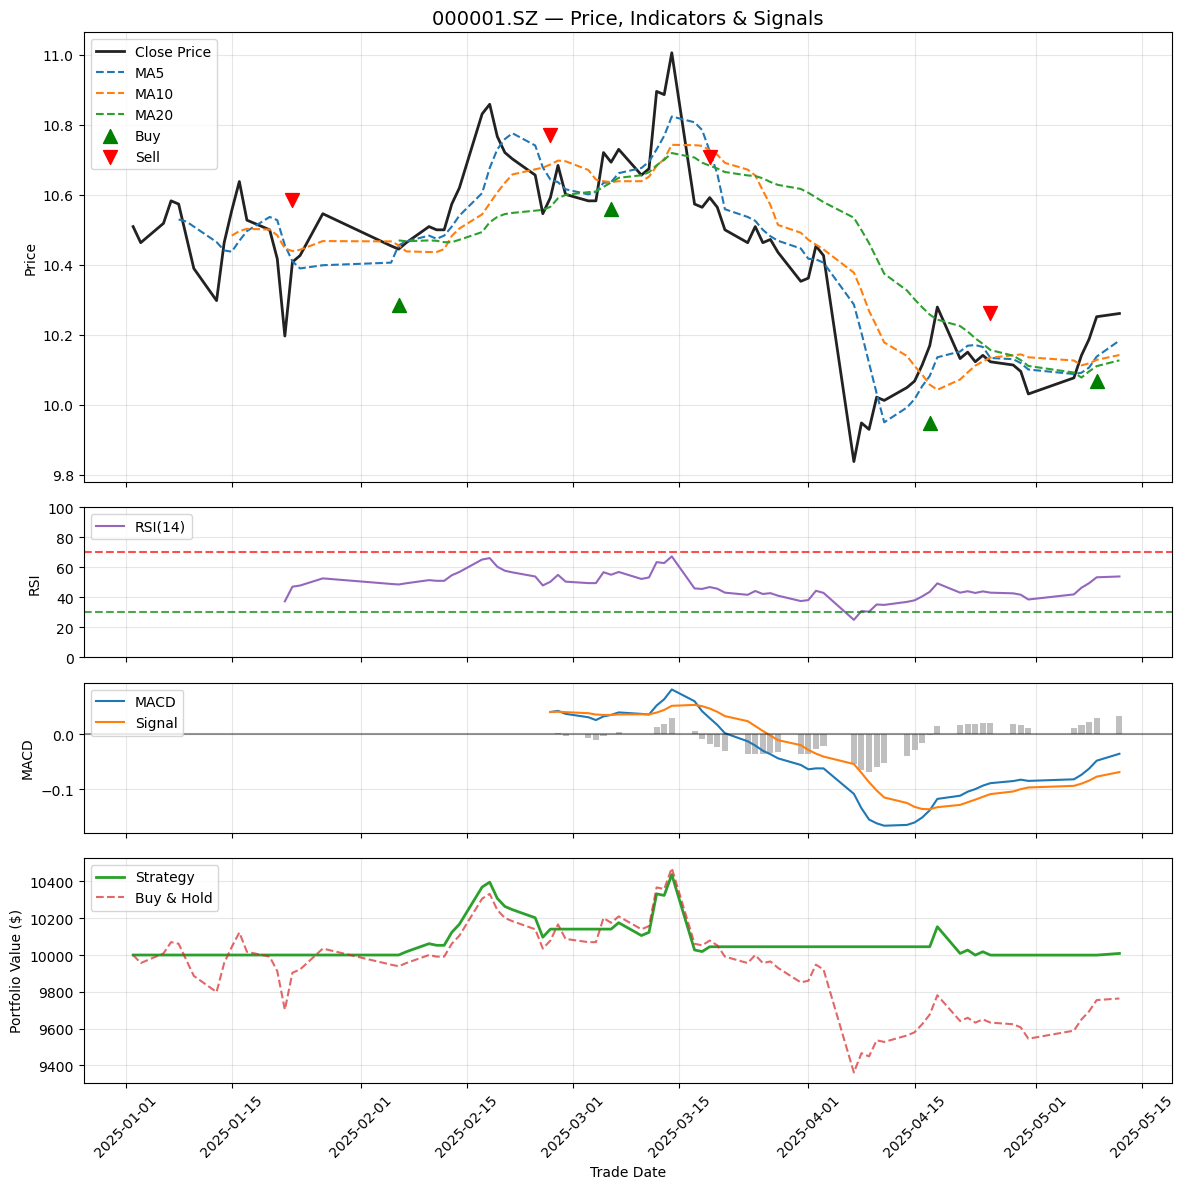

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import talib

# --------------------------
# 1. Configuration
# --------------------------
TICKER = "000001.SZ"
START_DATE = "2025-01-01"
END_DATE = "2025-05-13"
INITIAL_CAPITAL = 10000  # Define here so it's available everywhere

# Create folder if not exists
os.makedirs("data", exist_ok=True)

# --------------------------
# 2. Fetch & Clean Data
# --------------------------
df = yf.download(
    tickers=TICKER,
    start=START_DATE,
    end=END_DATE,
    progress=False
)

# Fix YFinance multi-index structure
df = df.droplevel("Ticker", axis=1)
df = df.reset_index()
df = df.rename(columns={
    "Date": "trade_date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "vol"
})

df = df[["trade_date", "open", "high", "low", "close", "vol"]]
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)

# --------------------------
# 3. Calculate Indicators with TA-Lib
# --------------------------
close = df["close"].values

df["MA5"] = talib.SMA(close, timeperiod=5)
df["MA10"] = talib.SMA(close, timeperiod=10)
df["MA20"] = talib.SMA(close, timeperiod=20)
df["RSI"] = talib.RSI(close, timeperiod=14)

macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
df["MACD"] = macd
df["MACD_Signal"] = macd_signal
df["MACD_Hist"] = macd_hist

# --------------------------
# 4. Generate Buy/Sell Signals
# --------------------------
df["Buy_Signal"] = 0.0
df["Sell_Signal"] = 0.0

for i in range(1, len(df)):
    # Buy condition: MA5 crosses above MA10 + RSI < 70
    if (df["MA5"].iloc[i] > df["MA10"].iloc[i] and
        df["MA5"].iloc[i-1] <= df["MA10"].iloc[i-1] and
        df["RSI"].iloc[i] < 70):
        df.loc[i, "Buy_Signal"] = df["low"].iloc[i] * 0.99

    # Sell condition: MA5 crosses below MA10 + RSI > 30
    if (df["MA5"].iloc[i] < df["MA10"].iloc[i] and
        df["MA5"].iloc[i-1] >= df["MA10"].iloc[i-1] and
        df["RSI"].iloc[i] > 30):
        df.loc[i, "Sell_Signal"] = df["high"].iloc[i] * 1.01

# --------------------------
# 5. Backtest Function
# --------------------------
def backtest_strategy(df, initial_capital):
    capital = float(initial_capital)
    shares = 0
    position = 0
    trades = []

    bt_df = df.copy()
    bt_df["Position"] = 0
    bt_df["Portfolio_Value"] = 0.0

    for i in range(len(bt_df)):
        price = float(bt_df["close"].iloc[i])
        date = bt_df["trade_date"].iloc[i]

        if bt_df["Buy_Signal"].iloc[i] > 0 and position == 0:
            shares = int(capital // price)
            capital -= shares * price
            position = 1
            trades.append({
                "date": date,
                "type": "BUY",
                "price": round(price, 3),
                "shares": shares
            })

        elif bt_df["Sell_Signal"].iloc[i] > 0 and position == 1:
            capital += shares * price
            trades.append({
                "date": date,
                "type": "SELL",
                "price": round(price, 3),
                "shares": shares
            })
            shares = 0
            position = 0

        bt_df.loc[i, "Position"] = position
        bt_df.loc[i, "Portfolio_Value"] = round(capital + shares * price, 2)

    if position == 1:
        capital += shares * float(bt_df["close"].iloc[-1])

    final_value = round(capital, 2)
    total_return_pct = round((final_value - initial_capital) / initial_capital * 100, 2)
    closed_trades = [t for t in trades if t["type"] == "SELL"]
    num_trades = len(closed_trades)
    win_trades = 0
    total_profit = 0.0

    for j in range(0, len(trades)-1, 2):
        if j+1 >= len(trades):
            break
        profit = (trades[j+1]["price"] - trades[j]["price"]) * trades[j]["shares"]
        total_profit += profit
        if profit > 0:
            win_trades += 1

    win_rate = round(win_trades / num_trades * 100, 2) if num_trades > 0 else 0.0

    summary = {
        "Initial Capital ($)": initial_capital,
        "Final Capital ($)": final_value,
        "Total Return (%)": total_return_pct,
        "Number of Closed Trades": num_trades,
        "Win Rate (%)": win_rate,
        "Total Profit ($)": round(total_profit, 2)
    }

    return summary, bt_df, trades

# --------------------------
# 6. Run Backtest
# --------------------------
summary, bt_df, trades = backtest_strategy(df, initial_capital=INITIAL_CAPITAL)

# Print results
print("=" * 50)
print("📈 BACKTEST SUMMARY")
print("=" * 50)
for k, v in summary.items():
    print(f"{k:<24} : {v}")

print("\n📋 TRADE LOG:")
print("-" * 50)
for t in trades:
    print(f"{t['date'].strftime('%Y-%m-%d')} | {t['type']:4} | Price: {t['price']:>7.3f} | Shares: {t['shares']:>5}")

# Save files
df.to_csv("data/000001.SZ_with_indicators.csv", index=False)
bt_df.to_csv("data/000001.SZ_backtest.csv", index=False)
print("\n✅ Files saved to /data folder")

# --------------------------
# 7. Plot All Charts
# --------------------------
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    nrows=4, figsize=(12, 12), sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1, 1.5]}
)

# --- Price + MAs + Signals ---
ax1.plot(df["trade_date"], df["close"], label="Close Price", linewidth=2, color="#222222")
ax1.plot(df["trade_date"], df["MA5"], label="MA5", linestyle="--", color="#1f77b4")
ax1.plot(df["trade_date"], df["MA10"], label="MA10", linestyle="--", color="#ff7f0e")
ax1.plot(df["trade_date"], df["MA20"], label="MA20", linestyle="--", color="#2ca02c")

ax1.scatter(df.loc[df["Buy_Signal"]>0, "trade_date"],
            df.loc[df["Buy_Signal"]>0, "Buy_Signal"],
            marker="^", color="green", s=100, label="Buy", zorder=5)
ax1.scatter(df.loc[df["Sell_Signal"]>0, "trade_date"],
            df.loc[df["Sell_Signal"]>0, "Sell_Signal"],
            marker="v", color="red", s=100, label="Sell", zorder=5)

ax1.set_title(f"{TICKER} — Price, Indicators & Signals", fontsize=14)
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# --- RSI ---
ax2.plot(df["trade_date"], df["RSI"], color="#9467bd", label="RSI(14)")
ax2.axhline(70, color="red", linestyle="--", alpha=0.7)
ax2.axhline(30, color="green", linestyle="--", alpha=0.7)
ax2.set_ylabel("RSI")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 100)

# --- MACD ---
ax3.plot(df["trade_date"], df["MACD"], color="#1f77b4", label="MACD")
ax3.plot(df["trade_date"], df["MACD_Signal"], color="#ff7f0e", label="Signal")
ax3.bar(df["trade_date"], df["MACD_Hist"], color="gray", alpha=0.5)
ax3.axhline(0, color="black", linestyle="-", alpha=0.4)
ax3.set_ylabel("MACD")
ax3.legend(loc="upper left")
ax3.grid(alpha=0.3)

# --- Equity Curve ---
bt_df["BuyHold_Value"] = INITIAL_CAPITAL * (bt_df["close"] / bt_df["close"].iloc[0])
ax4.plot(bt_df["trade_date"], bt_df["Portfolio_Value"], label="Strategy", color="#2ca02c", linewidth=2)
ax4.plot(bt_df["trade_date"], bt_df["BuyHold_Value"], label="Buy & Hold", color="#d62728", linestyle="--", alpha=0.7)
ax4.set_xlabel("Trade Date")
ax4.set_ylabel("Portfolio Value ($)")
ax4.legend(loc="upper left")
ax4.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()